# **01 - Analyse exploratoire et prétraitement des avis clients**

Prétraitement des avis (bilingues) :
- détection de langue, nettoyage, tokenisation, lemmatisation
- sauvegarde des données préparées pour les analyses et assistants

## **Imports**

In [11]:

# imports pour le preprocessing
import pandas as pd
import pyarrow
import numpy as np
import random
import matplotlib.pyplot as plt
import spacy
from langdetect import DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [31]:
import importlib
import sys
importlib.reload(sys.modules['utils.text_preprocessor'])
importlib.reload(pd)

<module 'pandas' from '/workspaces/assistant-rag/env/lib/python3.12/site-packages/pandas/__init__.py'>

In [32]:
# Custom imports
from utils.lang_detector import detecter_langue
from utils.text_preprocessor import nettoyer_texte, appliquer_traitement_ligne, appliquer_filtrage, filtrer_ponctuation

In [14]:
# installation des packages `spaCy` nécessaires
!python -m spacy download fr_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 54.6 MB/s  0:00:00m0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 49.3 MB/s  0:00:00m0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [15]:
# configuration
DetectorFactory.seed = 42
np.random.seed(42)
random.seed(42)

PROJET_ROOT = Path.cwd().parent.parent
DATA_PART1 = PROJET_ROOT / "data" / "part-1"
DATA_PART2 = PROJET_ROOT / "data" / "part-2"
DATA_PART3 = PROJET_ROOT / "data" / "part-3"
SAVE_DIR = PROJET_ROOT / "data" / "processed"
SAVE_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_colwidth', 200)

In [16]:
# chargement des modèles spaCy
nlp_fr = spacy.load("fr_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")
print("Modèles spaCy chargés")

Modèles spaCy chargés


## **Exploration des avis clients**

In [34]:
# chargement des avis clients sans header
chemin_csv = DATA_PART1 / "all_comments_ottawa.csv"
df_avis = pd.read_csv(chemin_csv, header=None, names=['avis'])
df_avis.head()

,avis
0,Chambre confortable mais décoration un peu démodée. Le petit-déjeuner est bon mais sans originalité particulière.
1,Le spa propose un traitement signature exclusif développé avec un aromathérapeute de renommée mondiale spécialement pour Hotel De La Promenade.
2,Un séjour correct mais qui ne justifie pas pleinement son classement luxe. Service professionnel mais sans cette touche personnelle qui fait la différence.
3,The laundry service express saved our gala dinner following a last-minute incident.
4,L'exposition de collection d'art contemporain de l'hôtel est présentée lors de visites privées par un historien d'art passionné qui en révèle toutes les subtilités.


In [36]:
# structure du dataframe
df_avis.info()

<class 'pandas.DataFrame'>
RangeIndex: 5946 entries, 0 to 5945
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   avis    5946 non-null   str  
dtypes: str(1)
memory usage: 4.5 MB


In [37]:
# valeurs manquantes
df_avis.isnull().sum()

avis    0
dtype: int64

In [38]:
# échantillon aléatoire pour visualiser la diversité des avis
df_avis.sample(5)

,avis
351,The ballroom with historical significance where we celebrated our anniversary seamlessly blends bygone elegance with contemporary amenities.
5549,"We stayed 5 nights at Hotel De La Promenade and I would have checked out if I had not pre-paid. The room on the 28th floor was just plain small, one upright chair at the desk from which I had to m..."
1619,"So who hasn't dreamt of staying at Hotel De La Promenade, well I have, and when I got the opportunity I just went for it. Location, lobby very good, but the rooms are at best just average. Small, ..."
1241,"This hotel must be one of the most overpriced hotels in Ottawa! We paid 657 CAD/Night for a out-dated rather small twin bed room without breakfast. One thing is for sure, I will absolutely never e..."
4152,"Hotel De La Promenade does live up to its reputation, although in parts, it is becoming rather dated.\nThe staff were the friendliest and most helpful I have met in a hotel to date. The lobby area..."


**Détectons la langue de chaque avis, grâce à `langdetect`**

In [39]:
# détection de la langue pour chaque avis
df_avis['langue'] = df_avis['avis'].apply(detecter_langue)
df_avis[['avis', 'langue']].sample(10)

,avis,langue
3976,This was a great location. Thanks to Jean-Pierre at the front desk we got upgraded to a suite with separate lounge and two bathrooms which was really appreciated for our six night stay. Handy to e...,en
4405,"I stayed at Hotel De La Promenade for a business conference in March 2007 and found my stay to be very comfortable. This was my first trip to Ottawa, and I was very impressed by Hotel De La Promen...",en
818,"Contrary to other reviewers, we found this a really great hotel, full of history & Art Deco/nouveau class. Staff are efficient, helpful & not over-efficious, just good at their jobs & friendly. Tr...",en
5574,"On dirait qu’avec la crise, Hotel De La Promenade s’est ouvert aux voyageurs moins fortuné. Du coup l’accueil n’est pas très aimable et la chambre donne sur un mur… presque pas de lumière naturell...",fr
532,Le restaurant principal de Hotel De La Promenade est créatif et savoureux. Les portions artistiques sont parfois trop minimalistes.,fr
984,Lots of bad reviews on here but I enjoyed it very much. The suite (in the Residences) was very comfortable and I slept marvelously. There was no sense of it being “tired” as some people have state...,en
366,Hygiène lamentable avec draps visiblement usagés et salle de bain mal entretenue. Totalement inacceptable quelle que soit la catégorie d'hôtel.,fr
1384,"After reading the reviews, I was a bit concerned but this hotel is such a legend I booked it anyway. I'm so thrilled I did! The room was fantastic, although was a mini suite, and the beds were the...",en
5008,This best part about this hotel is that it has a great location! Parliament Hill is around the corner (you can take the train from Ottawa airport right to Parliament Hill for about $15 - takes abo...,en
3304,Hotel De La Promenade\n\nGreat location\nBusier than the Rideau Canal with more traffic\nSmall 3 star quality rooms\nConstant construction noise – heard significant hammering starting at 10am\nVer...,en


**Bon, 10 échantillons et 100% anglais ?. Intéressant.**

In [40]:
# distribution des langues
df_avis['langue'].value_counts()

langue
en    5035
fr     910
it       1
Name: count, dtype: int64

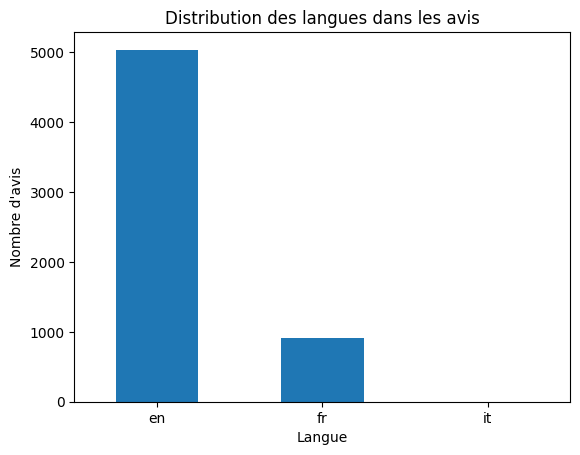

In [41]:
# visualisation
df_avis['langue'].value_counts().plot(kind='bar')
plt.title("Distribution des langues dans les avis")
plt.xlabel("Langue")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)
plt.show()

## **Nettoyage**

In [42]:
# nettoyage de base : suppression des sauts de ligne et caractères spéciaux
df_avis['avis_nettoye'] = df_avis['avis'].apply(nettoyer_texte)
df_avis[['avis', 'avis_nettoye']].head(3)

,avis,avis_nettoye
0,Chambre confortable mais décoration un peu démodée. Le petit-déjeuner est bon mais sans originalité particulière.,Chambre confortable mais décoration un peu démodée. Le petit-déjeuner est bon mais sans originalité particulière.
1,Le spa propose un traitement signature exclusif développé avec un aromathérapeute de renommée mondiale spécialement pour Hotel De La Promenade.,Le spa propose un traitement signature exclusif développé avec un aromathérapeute de renommée mondiale spécialement pour Hotel De La Promenade.
2,Un séjour correct mais qui ne justifie pas pleinement son classement luxe. Service professionnel mais sans cette touche personnelle qui fait la différence.,Un séjour correct mais qui ne justifie pas pleinement son classement luxe. Service professionnel mais sans cette touche personnelle qui fait la différence.


**Le nettoyage n'a rien changé car il n'y avait pas de sauts de ligne dans ces échantillons. C'est normal.**

## **Tokenisation & Lemmatisation (En/Fr - specific)**

In [43]:
# tokenisation et lemmatisation selon la langue
df_avis[['tokens', 'lemmes']] = df_avis.apply(appliquer_traitement_ligne, axis=1)

In [44]:
df_avis.head(5) # affichage des 5 premiers avis avec toutes les colonnes

,avis,langue,avis_nettoye,tokens,lemmes
0,Chambre confortable mais décoration un peu démodée. Le petit-déjeuner est bon mais sans originalité particulière.,fr,Chambre confortable mais décoration un peu démodée. Le petit-déjeuner est bon mais sans originalité particulière.,"[Chambre, confortable, mais, décoration, un, peu, démodée, ., Le, petit-déjeuner, est, bon, mais, sans, originalité, particulière, .]","[chambre, confortable, mais, décoration, un, peu, démoder, ., le, petit-déjeuner, être, bon, mais, sans, originalité, particulier, .]"
1,Le spa propose un traitement signature exclusif développé avec un aromathérapeute de renommée mondiale spécialement pour Hotel De La Promenade.,fr,Le spa propose un traitement signature exclusif développé avec un aromathérapeute de renommée mondiale spécialement pour Hotel De La Promenade.,"[Le, spa, propose, un, traitement, signature, exclusif, développé, avec, un, aromathérapeute, de, renommée, mondiale, spécialement, pour, Hotel, De, La, Promenade, .]","[le, spa, proposer, un, traitement, signatur, exclusif, développé, avec, un, aromathérapeute, de, renommée, mondial, spécialemer, pour, Hotel, de, le, promenade, .]"
2,Un séjour correct mais qui ne justifie pas pleinement son classement luxe. Service professionnel mais sans cette touche personnelle qui fait la différence.,fr,Un séjour correct mais qui ne justifie pas pleinement son classement luxe. Service professionnel mais sans cette touche personnelle qui fait la différence.,"[Un, séjour, correct, mais, qui, ne, justifie, pas, pleinement, son, classement, luxe, ., Service, professionnel, mais, sans, cette, touche, personnelle, qui, fait, la, différence, .]","[un, séjour, correct, mais, qui, ne, justifier, pas, pleinement, son, classement, lux, ., service, professionnel, mais, sans, ce, touche, personnel, qui, faire, le, différence, .]"
3,The laundry service express saved our gala dinner following a last-minute incident.,en,The laundry service express saved our gala dinner following a last-minute incident.,"[The, laundry, service, express, saved, our, gala, dinner, following, a, last, -, minute, incident, .]","[the, laundry, service, express, save, our, gala, dinner, follow, a, last, -, minute, incident, .]"
4,L'exposition de collection d'art contemporain de l'hôtel est présentée lors de visites privées par un historien d'art passionné qui en révèle toutes les subtilités.,fr,L'exposition de collection d'art contemporain de l'hôtel est présentée lors de visites privées par un historien d'art passionné qui en révèle toutes les subtilités.,"[L', exposition, de, collection, d', art, contemporain, de, l', hôtel, est, présentée, lors, de, visites, privées, par, un, historien, d', art, passionné, qui, en, révèle, toutes, les, subtilités, .]","[le, exposition, de, collection, de, art, contemporain, de, le, hôtel, être, présenter, lors, de, visite, priver, par, un, historien, de, art, passionner, qui, en, révèle, tout, le, subtilité, .]"


## **Gestion des `Stopwords` (En/Fr - specific)**

In [45]:
# filtrage des stopwords
df_avis[['tokens_sans_stop', 'lemmes_sans_stop']] = df_avis.apply(appliquer_filtrage, axis=1)

In [46]:
df_avis[['avis_nettoye', 'langue', 'tokens_sans_stop']].head(3)

,avis_nettoye,langue,tokens_sans_stop
0,Chambre confortable mais décoration un peu démodée. Le petit-déjeuner est bon mais sans originalité particulière.,fr,"[Chambre, confortable, décoration, démodée, ., petit-déjeuner, bon, originalité, particulière, .]"
1,Le spa propose un traitement signature exclusif développé avec un aromathérapeute de renommée mondiale spécialement pour Hotel De La Promenade.,fr,"[spa, propose, traitement, signature, exclusif, développé, aromathérapeute, renommée, mondiale, spécialement, Hotel, Promenade, .]"
2,Un séjour correct mais qui ne justifie pas pleinement son classement luxe. Service professionnel mais sans cette touche personnelle qui fait la différence.,fr,"[séjour, correct, justifie, pleinement, classement, luxe, ., Service, professionnel, touche, personnelle, différence, .]"


**Des caractères spéciaux se sont de nouveau introduits**

In [47]:
# filtrage des ponctuations ('., !?;:()[]{}' etc.)
df_avis['tokens_clean'], df_avis['lemmes_clean'] = zip(*df_avis.apply(
    lambda row: filtrer_ponctuation(row['tokens_sans_stop'], row['lemmes_sans_stop']), axis=1
))

In [48]:
df_avis[['avis_nettoye', 'langue', 'tokens_clean']].head(3)

,avis_nettoye,langue,tokens_clean
0,Chambre confortable mais décoration un peu démodée. Le petit-déjeuner est bon mais sans originalité particulière.,fr,"[Chambre, confortable, décoration, démodée, petit-déjeuner, bon, originalité, particulière]"
1,Le spa propose un traitement signature exclusif développé avec un aromathérapeute de renommée mondiale spécialement pour Hotel De La Promenade.,fr,"[spa, propose, traitement, signature, exclusif, développé, aromathérapeute, renommée, mondiale, spécialement, Hotel, Promenade]"
2,Un séjour correct mais qui ne justifie pas pleinement son classement luxe. Service professionnel mais sans cette touche personnelle qui fait la différence.,fr,"[séjour, correct, justifie, pleinement, classement, luxe, Service, professionnel, touche, personnelle, différence]"


In [52]:
df_avis.info()

<class 'pandas.DataFrame'>
RangeIndex: 5946 entries, 0 to 5945
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   avis              5946 non-null   str   
 1   langue            5946 non-null   str   
 2   avis_nettoye      5946 non-null   str   
 3   tokens            5946 non-null   object
 4   lemmes            5946 non-null   object
 5   tokens_sans_stop  5946 non-null   object
 6   lemmes_sans_stop  5946 non-null   object
 7   tokens_clean      5946 non-null   object
 8   lemmes_clean      5946 non-null   object
dtypes: object(6), str(3)
memory usage: 9.2+ MB


## **Sauvegarde**

In [50]:
# sauvegarde du point de contrôle
df_avis.to_parquet(SAVE_DIR / "avis_preprocesses.parquet")
print(f"avis sauvegardés dans {SAVE_DIR}/avis_preprocesses.parquet")

avis sauvegardés dans /workspaces/assistant-rag/data/processed/avis_preprocesses.parquet


## **Recapitulatif:**

Dans ce notebook, nous avons préparé les avis clients pour l'analyse. Face au bilinguisme des données, nous avons opté pour une détection automatique de la langue (En/Fr) et un traitement adapté via spaCy.

**Défis** : Correction du header du CSV (première ligne chargée comme en-tête), adaptation des modèles spaCy selon la langue.

**Réalisations** :
- 5946 avis traités (84.7% anglais, 15.3% français)
- Tokenisation, lemmatisation et filtrage des stop words
- Sauvegarde du point de contrôle `avis_preprocesses.parquet`

**Choix techniques :** Sauvegarde en format Parquet pour préserver les listes (tokens, lemmes) sans conversion en string, contrairement au CSV

**Pour la suite** : Analyse thématique à partir des lemmes filtrés.